In [241]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [242]:
Länge_Fehler = 1# in mm
Länge = [(980,67, 42.5),(960,46,22),(950,35.5,12.5)]   # (oben, oben_kugel, unten_kugel) in mm

Ls_oben = [ufloat(x[0],Länge_Fehler) - ufloat(x[1],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm
Ls_unten = [ufloat(x[0],Länge_Fehler) - ufloat(x[2],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm


Ls_oben

[913.0+/-1.4142135623730951,
 914.0+/-1.4142135623730951,
 914.5+/-1.4142135623730951]

In [243]:
def Fehler_des_Mittelwerts(array, n = 3):
    return np.std(array,ddof=1) / np.sqrt(n)

def nom(array):
    return [x.nominal_value for x in array]

Fehler_des_Mittelwerts(nom(Ls_unten))

Fehler_L_oben = np.sqrt(Fehler_des_Mittelwerts(nom(Ls_oben)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2)
Fehler_L_oben
L_oben = ufloat(np.average(nom(Ls_oben)),Fehler_L_oben)


L_unten = ufloat(np.average(nom(Ls_unten)),np.sqrt(Fehler_des_Mittelwerts(nom(Ls_unten)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2))


L = ((L_oben + L_unten) / 2) / 1000 #- 0.001
print(L)

0.9257+/-0.0010


In [244]:

# Bestimmen von detla t
Fehler_Zeitmessung = 0.2
Ts = [38.56,38.7,38.62,38.62,38.61]

T = (ufloat(np.average(Ts),Fehler_des_Mittelwerts(Ts, n=5)) + ufloat(0, Fehler_Zeitmessung)) / 20
           
print(T)

1.931+/-0.010


In [245]:

delta_t = T.std_dev * 20 # delta kleines t
n = 2 * delta_t / T.nominal_value * L.nominal_value / (0.3 * L.std_dev)
print(n)



626.0458011140737


In [246]:
Durchmesser_Kugel = ufloat(24.0,0.05) # in mm
Durchmesser_Kugel /= 1000 # in m



In [247]:
# Lange Messung
Reaktionszeit= 0.2
T_ges = ufloat(23 * 60 + 09.72,Reaktionszeit)
N = 1440 / 2

Ablesegenauigkeit = 1
Amplitudenmessung = [(0,18.2,0),
             (62,17.2,60.3),
             (110,16.3,45.5),
             (162,15.4,50.91),
             (212,14.9,48.35),
             (258,14.4,43.73),
             (306,13.8,46.54),
             (362,13.3,0),
             (450,12.4,139.23),
             (500,12.0,48.33),
             (546,11.6,44.13),
             (612,11.1,63.75),
             (670,10.7,55.73),
             (702,10.5,30.90),
             (760,10.1,55.92),
             (806,9.8,44.82),
             (860,9.5,51.99),
             (910,9.2,47.99),
             (970,8.9,57.98),
             (1002,8.8,30.88),
             (1050,8.6,46.13),
             (1100,8.3,48.11),
             (1148,8.1,46.48),
             (1202,7.9,52.00),
             (1250,7.7,0),
             (1298,7.5,93.14),
             (1348,7.3,48.11),
             (1400,7.1,50.39)          
            ] # (Anzahl Nulldurchgänge,Auslenknug, Delta Zeit)

print(T_ges / N)

print(len(Amplitudenmessung))

1.93017+/-0.00028
28


In [248]:

N_Nulldurchgänge,Amplitude_waagrecht, Delta_T = zip(*Amplitudenmessung)
Amplitude_waagrecht = np.array(Amplitude_waagrecht) / 100
Delta_T = np.array(Delta_T)

Delta_Nulldurchgänge = [0]+ [(N_Nulldurchgänge[x+1] - N_Nulldurchgänge[x]) / 2 for x in range(len(Amplitudenmessung) - 1)]
#print("\n".join([str(x) for x in list(zip(Delta_T / T.nominal_value,Delta_Nulldurchgänge))]))
N_Perioden = np.array(N_Nulldurchgänge) / 2
print(sum(Delta_T))

1351.3400000000001


In [249]:

def Exponential_Function(t, a,delta):
    return a * np.e ** (delta * t)
    
Höhe_Amplitudenmessung = ufloat(92,2) / 1000 # m
Unterkante_Kugel = ufloat(13,1) / 1000 # m 
Aufhängung = ufloat(950,1) / 1000
Messhöhe = Aufhängung - Höhe_Amplitudenmessung 
Amplitude = unp.arctan(unp.uarray(Amplitude_waagrecht,[0.002] * len(Amplitude_waagrecht)) / Messhöhe)

(a_fit,delta_fit), cov = scipy.optimize.curve_fit(Exponential_Function, N_Perioden, unp.nominal_values(Amplitude), sigma=[0.001] * len(Amplitude), absolute_sigma=True,bounds=([0,-0.1],[1,0.1]))
print(a_fit, delta_fit)
error = np.sqrt(np.diag(cov))
d_a_fit, d_delta_fit = error

print(error)

0.1999856159965623 -0.0013516710010562207
[4.54886588e-04 7.28203559e-06]


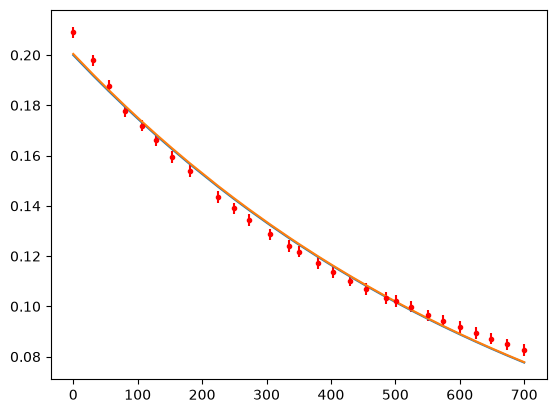

In [250]:
plt.errorbar(N_Perioden,nom(Amplitude),unp.std_devs(Amplitude), fmt="r.")
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit,delta_fit))
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit+d_a_fit,delta_fit))

0.002610+/-0.000035


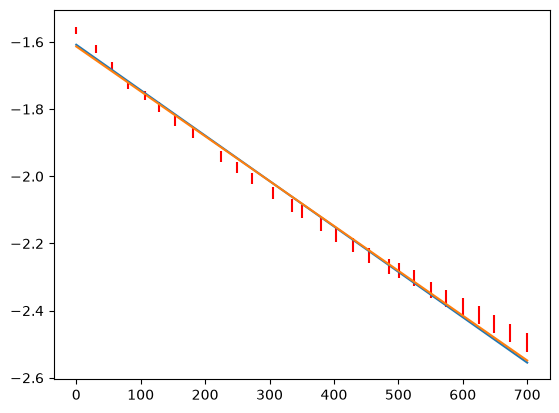

In [251]:
Amplitude_log = unp.log(unp.uarray(nom(Amplitude),unp.std_devs(Amplitude)))
Amplitude_log

def linear(x,m,b):
    return m * x + b
    
(m_fit,b_fit), cov = scipy.optimize.curve_fit(linear, N_Perioden, unp.nominal_values(Amplitude_log), sigma=unp.std_devs(Amplitude_log), absolute_sigma=True)

error = np.sqrt(np.diag(cov))
d_m_fit, d_b_fit = error
plt.errorbar(N_Perioden, unp.nominal_values(Amplitude_log), unp.std_devs(Amplitude_log),fmt="r,")
plt.plot(N_Perioden, linear(N_Perioden,m_fit,b_fit))
plt.plot(N_Perioden, linear(N_Perioden,m_fit + d_m_fit,b_fit-d_b_fit))

delta = -ufloat(m_fit, d_m_fit) * T
print(delta)

# Erste Rechnung für g

In [252]:
Radius_Kugel = Durchmesser_Kugel / 2
T = T_ges / N
rho_F = 7.83 * 1000 # kg/m^3
rho_L =  1.2041 # kg / m^3
r_Faden = 0.1 * 10**(-3) # m
V_Kugel = 4/3 * np.pi * Radius_Kugel ** 3
m_Kugel = rho_F * V_Kugel
m_Faden = L * rho_F * np.pi * r_Faden ** 2

print(m_Kugel)
print(m_Faden)
print(T)
print(L)

0.05668+/-0.00035
0.00022772+/-0.00000025
1.93017+/-0.00028
0.9257+/-0.0010


In [275]:
Korrektur_r_l = 2/5 * Radius_Kugel**2 / L**2 
Korrektur_dichte = rho_L/rho_F 
Korrektur_masse = 1/6 * m_Faden /m_Kugel


g_1 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_r_l + Korrektur_dichte - Korrektur_masse)
print(g_1)

print(Korrektur_r_l)
print(Korrektur_dichte)
print(Korrektur_masse)





9.805+/-0.011
(6.721+/-0.032)e-05
0.00015378033205619413
0.000670+/-0.000004



# Zweite Rechnung für g


In [276]:
omega_0 = 2 * np.pi / T
print(omega_0)

# phi_0 berechnen

Auslenkung_max =  ufloat(0.182,0.001)
tan_phi = Auslenkung_max / Messhöhe
phi_0 = unp.arctan([tan_phi])[0]
print(phi_0 / (2 * np.pi) * 360)

Korrektur_delta = delta**2 / omega_0**2
Korrektur_phi_0 = phi_0**2 / 8
print(Korrektur_delta, Korrektur_phi_0)

3.2553+/-0.0005
11.98+/-0.07
(6.43+/-0.17)e-07 0.00546+/-0.00006


In [255]:
g_2 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_r_l + Korrektur_dichte - Korrektur_masse + Korrektur_delta + Korrektur_phi_0)
print(g_2)


9.859+/-0.011


In [272]:
# Test der Korrektur entlang der Amplitude
print(type(phi_0), type(delta))
print(    Exponential_Function(1,phi_0.nominal_value,-delta.nominal_value))
def amplitude(t):    
    return Exponential_Function(t,phi_0.nominal_value,-delta.nominal_value)

def korrektur(amplitude):
    return amplitude**2 / 8
korrektur_amplitude = np.average(korrektur(amplitude(np.arange(0,T_ges.nominal_value))))
print(korrektur_amplitude)
g_3 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_r_l + Korrektur_dichte - Korrektur_masse + Korrektur_delta + korrektur_amplitude)
print(g_3)
#plt.plot(x,amplitude(x) / (2 * np.pi) * 360)

<class 'uncertainties.core.AffineScalarFunc'> <class 'uncertainties.core.AffineScalarFunc'>
0.2084780298256139
0.0007540149448425461
9.813+/-0.011


In [274]:
# Test der Korrektur entlang der Amplitude

def amplitude(t):    
    return Exponential_Function(t,phi_0.nominal_value,-delta.nominal_value)

def korrektur(amplitude):
    return amplitude**2 / 8
korrektur_amplitude = np.average(korrektur(amplitude(np.arange(0,T_ges.nominal_value))))
print(korrektur_amplitude)
g_3 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_r_l + Korrektur_dichte - Korrektur_masse + Korrektur_delta + korrektur_amplitude)
print(g_3)
#plt.plot(x,amplitude(x) / (2 * np.pi) * 360)

0.0007540149448425461
9.813+/-0.011
